# Task 04：DQN——学习与实验入口

## 本 Notebook 的学习边界

DQN 用神经网络近似动作价值：

$$
Q_	heta(s,a)pprox Q_*(s,a),\qquad y=r+\gamma(1-terminal)\max_{a'}Q_{	heta^-}(s',a').
$$

Replay Buffer 打破相邻样本相关性，Target Network 减少追逐自身目标造成的振荡。先检查网络输出和 buffer，再训练 CartPole，最后用单变量对照移除稳定化组件。


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import random

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch

from src.dqn_agent import DQNAgent

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [2]:
env = gym.make("CartPole-v1")

state, info = env.reset(seed=SEED)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("Initial state:", state)
print("State dim:", state_dim)
print("Action dim:", action_dim)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Initial state: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
State dim: 4
Action dim: 2
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


In [3]:
def linear_epsilon_decay(
    step,
    epsilon_start=1.0,
    epsilon_end=0.05,
    decay_steps=15_000,
):
    ratio = min(step / decay_steps, 1.0)

    return (
        epsilon_start
        + ratio * (epsilon_end - epsilon_start)
    )

In [4]:
NUM_EPISODES = 500

HIDDEN_DIM = 128
LR = 1e-3
GAMMA = 0.99

BATCH_SIZE = 64
BUFFER_CAPACITY = 50_000

# Replay Buffer 至少积累这么多 transition 后再开始学习
LEARNING_STARTS = 1000

# Online Network 更新多少次后同步一次 Target Network
TARGET_UPDATE_FREQ = 200

EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY_STEPS = 15_000

In [5]:
agent = DQNAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=HIDDEN_DIM,
    lr=LR,
    gamma=GAMMA,
    epsilon=EPSILON_START,
    batch_size=BATCH_SIZE,
    buffer_capacity=BUFFER_CAPACITY,
    target_update_freq=TARGET_UPDATE_FREQ,
    device=device,
)

print(agent.q_network)

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [6]:
episode_rewards = []
episode_lengths = []
losses = []
epsilon_history = []

global_step = 0


for episode in range(NUM_EPISODES):

    state, info = env.reset(seed=SEED + episode)

    episode_reward = 0.0
    episode_length = 0

    terminated = False
    truncated = False

    while not (terminated or truncated):

        # 1. epsilon decay
        agent.epsilon = linear_epsilon_decay(
            step=global_step,
            epsilon_start=EPSILON_START,
            epsilon_end=EPSILON_END,
            decay_steps=EPSILON_DECAY_STEPS,
        )

        # 2. epsilon-greedy 选择动作
        action = agent.select_action(state)

        # 3. 与环境交互
        (
            next_state,
            reward,
            terminated,
            truncated,
            info,
        ) = env.step(action)

        # 4. 保存 transition
        #
        # 注意：
        # terminated 才代表真正的 terminal state
        # truncated 只是因为时间限制等原因结束 episode
        agent.store_transition(
            state=state,
            action=action,
            reward=reward,
            next_state=next_state,
            done=terminated,
        )

        # 5. Replay Buffer 有足够经验后开始训练
        if len(agent.replay_buffer) >= LEARNING_STARTS:
            loss = agent.update()

            if loss is not None:
                losses.append(loss)

        # 6. 进入下一状态
        state = next_state

        episode_reward += reward
        episode_length += 1
        global_step += 1

    episode_rewards.append(episode_reward)
    episode_lengths.append(episode_length)
    epsilon_history.append(agent.epsilon)

    # 每 20 个 episode 输出一次
    if (episode + 1) % 20 == 0:

        avg_reward = np.mean(
            episode_rewards[-20:]
        )

        avg_length = np.mean(
            episode_lengths[-20:]
        )

        print(
            f"Episode {episode + 1:4d} | "
            f"Avg Reward: {avg_reward:7.2f} | "
            f"Avg Length: {avg_length:7.2f} | "
            f"Epsilon: {agent.epsilon:.3f} | "
            f"Buffer: {len(agent.replay_buffer)}"
        )

Episode   20 | Avg Reward:   22.95 | Avg Length:   22.95 | Epsilon: 0.971 | Buffer: 459
Episode   40 | Avg Reward:   23.45 | Avg Length:   23.45 | Epsilon: 0.941 | Buffer: 928
Episode   60 | Avg Reward:   25.10 | Avg Length:   25.10 | Epsilon: 0.909 | Buffer: 1430
Episode   80 | Avg Reward:   23.85 | Avg Length:   23.85 | Epsilon: 0.879 | Buffer: 1907
Episode  100 | Avg Reward:   24.20 | Avg Length:   24.20 | Epsilon: 0.849 | Buffer: 2391
Episode  120 | Avg Reward:   27.40 | Avg Length:   27.40 | Epsilon: 0.814 | Buffer: 2939
Episode  140 | Avg Reward:   28.05 | Avg Length:   28.05 | Epsilon: 0.778 | Buffer: 3500
Episode  160 | Avg Reward:   33.35 | Avg Length:   33.35 | Epsilon: 0.736 | Buffer: 4167
Episode  180 | Avg Reward:   50.20 | Avg Length:   50.20 | Epsilon: 0.673 | Buffer: 5171
Episode  200 | Avg Reward:   57.80 | Avg Length:   57.80 | Epsilon: 0.599 | Buffer: 6327
Episode  220 | Avg Reward:   45.45 | Avg Length:   45.45 | Epsilon: 0.542 | Buffer: 7236
Episode  240 | Avg Rewa

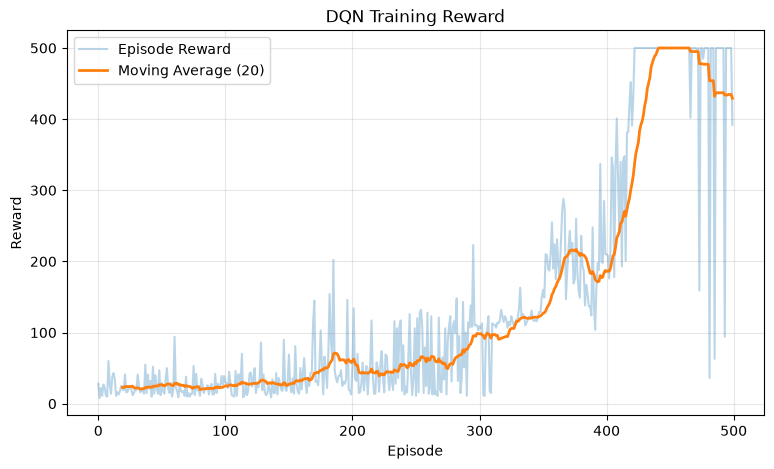

In [8]:
def moving_average(data, window_size=20):
    data = np.asarray(data, dtype=np.float32)

    if len(data) < window_size:
        return data

    return np.convolve(
        data,
        np.ones(window_size) / window_size,
        mode="valid",
    )

reward_ma = moving_average(
    episode_rewards,
    window_size=20,
)

plt.figure(figsize=(9, 5))

plt.plot(
    episode_rewards,
    alpha=0.3,
    label="Episode Reward",
)

plt.plot(
    np.arange(len(reward_ma)) + 19,
    reward_ma,
    linewidth=2,
    label="Moving Average (20)",
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Training Reward")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Last 20 episodes average reward: 429.25
Last 50 episodes average reward: 462.56
Maximum episode reward: 500.0
Final epsilon: 0.050000000000000044
Replay buffer size: 50000
Number of gradient updates: 71049


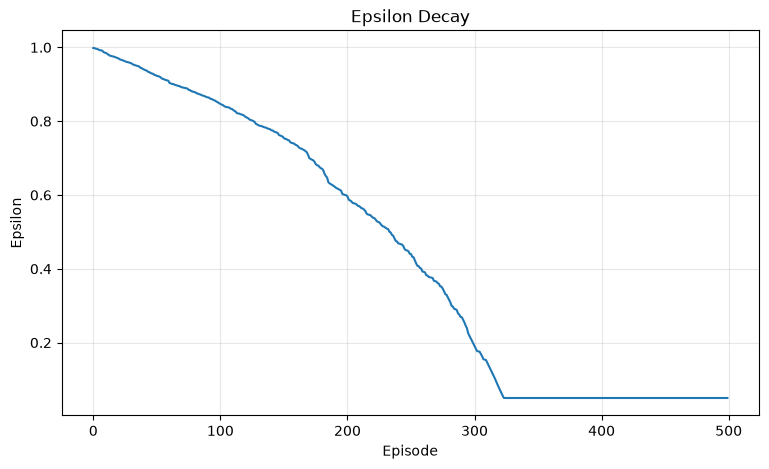

In [9]:
plt.figure(figsize=(9, 5))

plt.plot(epsilon_history)

plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay")
plt.grid(alpha=0.3)

print(
    "Last 20 episodes average reward:",
    np.mean(episode_rewards[-20:])
)

print(
    "Last 50 episodes average reward:",
    np.mean(episode_rewards[-50:])
)

print(
    "Maximum episode reward:",
    np.max(episode_rewards)
)

print(
    "Final epsilon:",
    agent.epsilon
)

print(
    "Replay buffer size:",
    len(agent.replay_buffer)
)

print(
    "Number of gradient updates:",
    agent.update_count
)

plt.show()

In [10]:
eval_env = gym.make("CartPole-v1")

NUM_EVAL_EPISODES = 20

eval_rewards = []

original_epsilon = agent.epsilon
agent.epsilon = 0.0


for episode in range(NUM_EVAL_EPISODES):

    state, info = eval_env.reset(
        seed=1000 + episode
    )

    terminated = False
    truncated = False

    episode_reward = 0.0

    while not (terminated or truncated):

        action = agent.select_action(state)

        (
            next_state,
            reward,
            terminated,
            truncated,
            info,
        ) = eval_env.step(action)

        state = next_state
        episode_reward += reward

    eval_rewards.append(episode_reward)


agent.epsilon = original_epsilon

eval_env.close()


print(
    "Evaluation Average Reward:",
    np.mean(eval_rewards)
)

print(
    "Evaluation Std:",
    np.std(eval_rewards)
)

print(
    "Evaluation Rewards:",
    eval_rewards
)

Evaluation Average Reward: 500.0
Evaluation Std: 0.0
Evaluation Rewards: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]


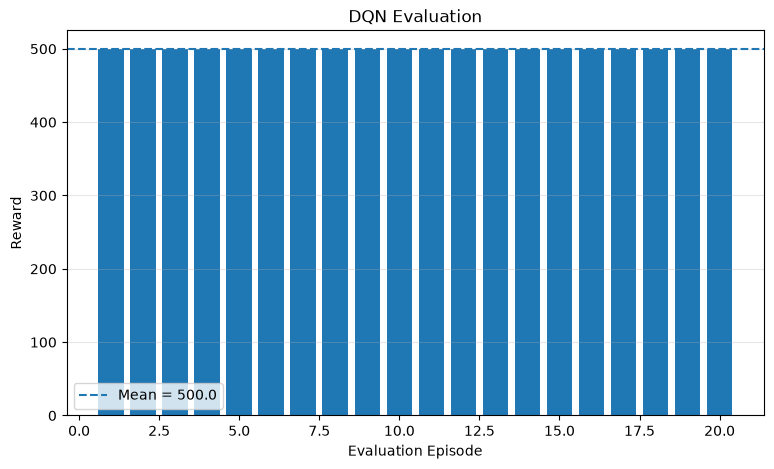

In [11]:
plt.figure(figsize=(9, 5))

plt.bar(
    np.arange(1, NUM_EVAL_EPISODES + 1),
    eval_rewards,
)

plt.axhline(
    np.mean(eval_rewards),
    linestyle="--",
    label=f"Mean = {np.mean(eval_rewards):.1f}",
)

plt.xlabel("Evaluation Episode")
plt.ylabel("Reward")
plt.title("DQN Evaluation")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [12]:
test_env = gym.make("CartPole-v1")

state, info = test_env.reset(seed=123)

state_tensor = torch.tensor(
    state,
    dtype=torch.float32,
    device=device,
).unsqueeze(0)


with torch.no_grad():

    online_q = agent.q_network(
        state_tensor
    )

    target_q = agent.target_network(
        state_tensor
    )


print("State:")
print(state)

print("\nOnline Q-values:")
print(online_q.cpu().numpy())

print("\nTarget Q-values:")
print(target_q.cpu().numpy())

print(
    "\nGreedy action:",
    online_q.argmax(dim=1).item()
)

test_env.close()

State:
[ 0.01823519 -0.0446179  -0.02796401 -0.03156282]

Online Q-values:
[[146.07729 144.77757]]

Target Q-values:
[[146.20506 144.19057]]

Greedy action: 0


## 实验结论与提交要求

运行完本 Notebook 后，不要只保留图。请在对应 `notes/` 中记录随机种子、环境版本、关键超参数、最终指标、曲线文件和一个失败现象。结论必须区分“代码运行成功”和“算法表现更好”：前者由自检确认，后者需要多 seed 或控制变量实验支持。

提交前从仓库根目录运行：

```bash
python eval/run.py
```
